In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os


In [4]:
df = pd.read_csv('C:\\Users\\ajitd\\OneDrive\\Desktop\\Work\\Data Science Projects\\AI_Job_Market_Dashboard\\Data\\ai_jobs_raw.csv')
df.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large


In [6]:
df.shape

(50000, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                50000 non-null  str  
 1   job_title             50000 non-null  str  
 2   company_type          50000 non-null  str  
 3   industry              50000 non-null  str  
 4   country               50000 non-null  str  
 5   city                  50000 non-null  str  
 6   remote_type           50000 non-null  str  
 7   experience_level      50000 non-null  str  
 8   min_experience_years  50000 non-null  int64
 9   salary_min_usd        50000 non-null  int64
 10  salary_max_usd        50000 non-null  int64
 11  employment_type       50000 non-null  str  
 12  posted_year           50000 non-null  int64
 13  company_size          50000 non-null  str  
dtypes: int64(4), str(10)
memory usage: 9.1 MB


In [8]:
## create avergae salary column
df['average_salary'] = (df['salary_min_usd'] + df['salary_max_usd']) / 2
df.average_salary.describe()

count     50000.000000
mean     110864.892530
std       37049.338755
min       57607.500000
25%       70673.875000
50%      107565.250000
75%      154331.750000
max      167468.000000
Name: average_salary, dtype: float64

In [9]:
## checking the experience level distribution
df.experience_level.value_counts()

experience_level
Mid       16695
Senior    16677
Entry     16628
Name: count, dtype: int64

In [11]:
## checking remote work  distribution
df.remote_type.value_counts().head(10)

remote_type
Hybrid    16984
Onsite    16538
Remote    16478
Name: count, dtype: int64

In [18]:
##check the unique countries
df["country"].nunique()
df["country"].value_counts().head(10)


country
UK           8452
India        8350
Germany      8345
Canada       8303
Australia    8276
USA          8274
Name: count, dtype: int64

In [19]:
### creating a flag for analyst roles
df['is_analyst'] = df['job_title'].str.contains('analyst', case=False, na=False)


In [20]:
df['is_analyst'].value_counts()

is_analyst
False    41740
True      8260
Name: count, dtype: int64

### EXPLORE THE DATA FURTHER 

In [24]:
## SALARY DISTRIBUTION
#### Which experience level earns the most?
#### Is the difference significant?
df.groupby('experience_level')['average_salary'].mean().sort_values(ascending=False)

experience_level
Senior    157490.178359
Mid       107507.124049
Entry      67473.507698
Name: average_salary, dtype: float64

#### Is the difference between experience levels significant?

Text(0.5, 1.0, 'Average Salary by Experience Level')

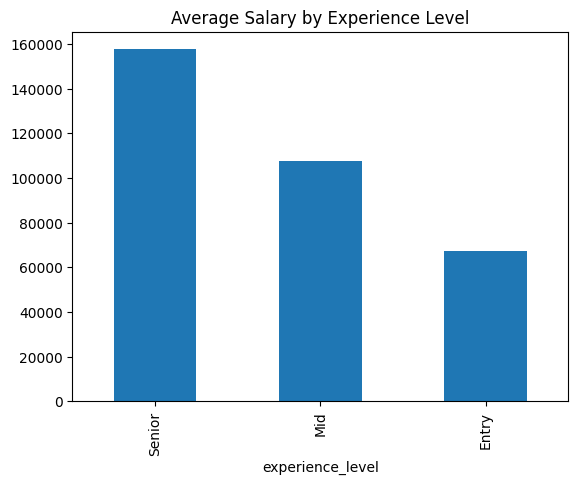

In [ ]:


df.groupby('experience_level')['average_salary'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Salary by Experience Level')


#### Do remote jobs pay more on average than non-remote jobs?

In [ ]:

df.groupby('remote_type')['average_salary'].mean().sort_values(ascending=False)

remote_type
Hybrid    111169.122969
Remote    110910.661033
Onsite    110506.855091
Name: average_salary, dtype: float64

#### Which industries pay the best for AI roles?

In [ ]:

df.groupby('industry')['average_salary'].mean().sort_values(ascending=False).head(10)

industry
Retail        111070.608628
Finance       111049.202106
Education     110796.990744
Healthcare    110735.411756
Tech          110674.773629
Name: average_salary, dtype: float64

#### Role analysis

In [66]:
df['role_family'] = 'Other'
df.loc[df['job_title'].str.contains('scientist',case=False), 'role_family'] = 'Data Scientist'
df.loc[df['job_title'].str.contains('analyst',case=False),'role_family'] = 'Data Analyst'
df.loc[df['job_title'].str.contains('engineer',case=False),'role_family'] = 'Engineer'
df.loc[df['job_title'].str.contains('researcher',case=False),'role_family'] = 'Researcher'
df['role_family'].value_counts().sort_values(ascending=False).head(10)


role_family
Data Scientist    16708
Engineer          16617
Researcher         8415
Data Analyst       8260
Name: count, dtype: int64

In [65]:
### Role family salary distribution
df.groupby('role_family')['average_salary'].mean().round(0).sort_values(ascending=False)

role_family
Data Analyst      111343.0
Data Scientist    111059.0
Engineer          110579.0
Researcher        110575.0
Name: average_salary, dtype: float64

In [38]:
df.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size,average_salary,is_analyst,role_family
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large,64548.0,False,Engineer
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium,70201.0,True,Data Analyst
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large,162893.0,False,Engineer
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium,69980.0,False,Data Scientist
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large,115137.5,False,Engineer


### Country intelligence

In [40]:
top_countries =df.groupby('country')['average_salary'].mean().sort_values(ascending=False).head(15)
top_countries

country
Australia    111485.412337
USA          111057.537165
UK           111039.290582
Germany      110897.890294
India        110396.954910
Canada       110314.312839
Name: average_salary, dtype: float64

In [42]:
### Average salary by company size
df.groupby('company_size')['average_salary'].mean().sort_values(ascending=False)


company_size
Large     110926.278492
Small     110903.200876
Medium    110765.317795
Name: average_salary, dtype: float64

In [43]:
### Average salary by emplyment type
df.groupby('employment_type')['average_salary'].mean().sort_values(ascending=False)

employment_type
Full-time    110864.89253
Name: average_salary, dtype: float64

In [45]:
### Average salary by seniority level
df.groupby('experience_level')['average_salary'].mean().sort_values(ascending=False)

experience_level
Senior    157490.178359
Mid       107507.124049
Entry      67473.507698
Name: average_salary, dtype: float64

In [48]:
### Average salary by industry
df.groupby('industry')['average_salary'].mean().sort_values(ascending=False).head(10)

industry
Retail        111070.608628
Finance       111049.202106
Education     110796.990744
Healthcare    110735.411756
Tech          110674.773629
Name: average_salary, dtype: float64

In [51]:
df.groupby('industry').agg({'average_salary':['mean','count']}).sort_values(('average_salary','mean'),ascending=False)

average_salary       
                     mean  count
industry                        
Retail      111070.608628   9979
Finance     111049.202106   9970
Education   110796.990744   9939
Healthcare  110735.411756  10029
Tech        110674.773629  10083

In [54]:
pd.crosstab(df['industry'], df['experience_level'])

experience_level,Entry,Mid,Senior
industry,,,
Education,3285,3366,3288
Finance,3364,3206,3400
Healthcare,3338,3385,3306
Retail,3294,3330,3355
Tech,3347,3408,3328


In [59]:
### Do entry level remote data professionals earn significantly less than senior remote data professionals?
df.groupby(['experience_level','remote_type'])['average_salary'].mean().round(0)

experience_level  remote_type
Entry             Hybrid          67479.0
                  Onsite          67506.0
                  Remote          67434.0
Mid               Hybrid         107446.0
                  Onsite         107562.0
                  Remote         107515.0
Senior            Hybrid         157552.0
                  Onsite         157434.0
                  Remote         157481.0
Name: average_salary, dtype: float64

In [63]:
## Do large companies pay more and does the gap widen at senior levels
df.groupby(['experience_level','company_size'])['average_salary'].mean().round(0).sort_values(ascending=False)

experience_level  company_size
Senior            Medium          157545.0
                  Large           157481.0
                  Small           157444.0
Mid               Large           107545.0
                  Medium          107513.0
                  Small           107464.0
Entry             Small            67522.0
                  Medium           67503.0
                  Large            67394.0
Name: average_salary, dtype: float64

In [64]:
###  Which industries pay senior talent most and which industries underpay entry level talent 
df.groupby(['industry','experience_level'])['average_salary'].mean().round(0)

industry    experience_level
Education   Entry                67516.0
            Mid                 107512.0
            Senior              157401.0
Finance     Entry                67433.0
            Mid                 107475.0
            Senior              157574.0
Healthcare  Entry                67506.0
            Mid                 107577.0
            Senior              157618.0
Retail      Entry                67499.0
            Mid                 107498.0
            Senior              157396.0
Tech        Entry                67415.0
            Mid                 107473.0
            Senior              157461.0
Name: average_salary, dtype: float64

In [68]:
df.groupby('experience_level').agg({'average_salary':['mean','count']})

average_salary       
                           mean  count
experience_level                      
Entry              67473.507698  16628
Mid               107507.124049  16695
Senior            157490.178359  16677

In [74]:
df.groupby(['company_size','experience_level']).agg({'average_salary':['mean','count']})

average_salary      
                                        mean count
company_size experience_level                     
Large        Entry              67394.492656  5515
             Mid               107544.610902  5577
             Senior            157480.999640  5562
Medium       Entry              67503.247684  5612
             Mid               107513.250864  5495
             Senior            157545.081838  5572
Small        Entry              67522.383748  5501
             Mid               107463.956518  5623
             Senior            157444.197817  5543

In [75]:
df.to_csv('C:\\Users\\ajitd\\OneDrive\\Desktop\\Work\\Data Science Projects\\AI_Job_Market_Dashboard\\Data\\ai_jobs_cleaned.csv', index=False)